In [1]:
import pandas as pd

In [ ]:
#Queste sono le tabelle del consumo di energia elettrica per ogni casa, con una frequenza di 15 minuti.
Tabella_Load1 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House1.csv')
Tabella_Load2 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House2.csv')
Tabella_Load3 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House3.csv')
Tabella_Load4 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House4.csv')
Tabella_Load5 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House5.csv')
Tabella_Load11 = pd.read_csv(r'C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\5063428\CLEAN_House11.csv')

In [3]:
print(Tabella_Load1)
print(Tabella_Load2)
print(Tabella_Load3)
print(Tabella_Load4)
print(Tabella_Load5)
print(Tabella_Load11)

                        Time        Unix  Aggregate  Appliance1  Appliance2  \
0        2013-10-09 13:06:17  1381323977        523          74           0   
1        2013-10-09 13:06:31  1381323991        526          75           0   
2        2013-10-09 13:06:46  1381324006        540          74           0   
3        2013-10-09 13:07:01  1381324021        532          74           0   
4        2013-10-09 13:07:15  1381324035        540          74           0   
...                      ...         ...        ...         ...         ...   
6960003  2015-07-10 11:56:05  1436529365        187           0          45   
6960004  2015-07-10 11:56:12  1436529372        185           0          45   
6960005  2015-07-10 11:56:18  1436529378        181           0          45   
6960006  2015-07-10 11:56:25  1436529385        186           0          45   
6960007  2015-07-10 11:56:32  1436529392        182           0          45   

         Appliance3  Appliance4  Appliance5  Applia

In [4]:
# assicurati che la colonna Time sia datetime, altrimenti resample fallisce
for df in (Tabella_Load1, Tabella_Load2, Tabella_Load3,
		   Tabella_Load4, Tabella_Load5, Tabella_Load11):
	df['Time'] = pd.to_datetime(df['Time'])

#Trasformo le tabelle per il consumo orario dell'energia elettrica, con una frequenza di 1 ora,
#e le aggrego tra loro in modo che ogni colonna rappresenti il consumo di una casa.
Tabella_Load1_temp = Tabella_Load1.set_index("Time")
Tabella_Load2_temp = Tabella_Load2.set_index("Time")
Tabella_Load3_temp = Tabella_Load3.set_index("Time")
Tabella_Load4_temp = Tabella_Load4.set_index("Time")
Tabella_Load5_temp = Tabella_Load5.set_index("Time")
Tabella_Load11_temp = Tabella_Load11.set_index("Time")

Tabella_Load1_temp = Tabella_Load1_temp.resample("1h").mean()
Tabella_Load2_temp = Tabella_Load2_temp.resample("1h").mean()
Tabella_Load3_temp = Tabella_Load3_temp.resample("1h").mean()
Tabella_Load4_temp = Tabella_Load4_temp.resample("1h").mean()
Tabella_Load5_temp = Tabella_Load5_temp.resample("1h").mean()
Tabella_Load11_temp = Tabella_Load11_temp.resample("1h").mean()

Tabella_Load_temp = pd.concat(
	[Tabella_Load1_temp["Aggregate"],
	 Tabella_Load2_temp["Aggregate"],
	 Tabella_Load3_temp["Aggregate"],
	 Tabella_Load4_temp["Aggregate"],
	 Tabella_Load5_temp["Aggregate"],
	 Tabella_Load11_temp["Aggregate"]],
	axis=1
)
Tabella_Load_temp.columns = [
	"House1", "House2", "House3", "House4", "House5", "House11"
]

#devo dividere per 1000 per avere i valori in kW invece che in W
Tabella_Load_temp = Tabella_Load_temp / 1000

#Creo una colonna con la somma del consumo di tutte le case, che rappresenta il consumo totale della microgrid
Tabella_Load_temp["Total_Load"] = Tabella_Load_temp.sum(axis=1)
print(Tabella_Load_temp)

                       House1    House2  House3  House4  House5  House11  \
Time                                                                       
2013-09-17 22:00:00       NaN  0.277643     NaN     NaN     NaN      NaN   
2013-09-17 23:00:00       NaN  0.093307     NaN     NaN     NaN      NaN   
2013-09-18 00:00:00       NaN  0.093647     NaN     NaN     NaN      NaN   
2013-09-18 01:00:00       NaN  0.063625     NaN     NaN     NaN      NaN   
2013-09-18 02:00:00       NaN  0.091045     NaN     NaN     NaN      NaN   
...                       ...       ...     ...     ...     ...      ...   
2015-07-10 07:00:00  0.213995       NaN     NaN     NaN     NaN      NaN   
2015-07-10 08:00:00  0.220898       NaN     NaN     NaN     NaN      NaN   
2015-07-10 09:00:00  0.197615       NaN     NaN     NaN     NaN      NaN   
2015-07-10 10:00:00  0.211506       NaN     NaN     NaN     NaN      NaN   
2015-07-10 11:00:00  0.224207       NaN     NaN     NaN     NaN      NaN   

           

C:\Users\vinsc\AppData\Local\Temp\ipykernel_23772\3242142609.py:22: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  Tabella_Load_temp = pd.concat(


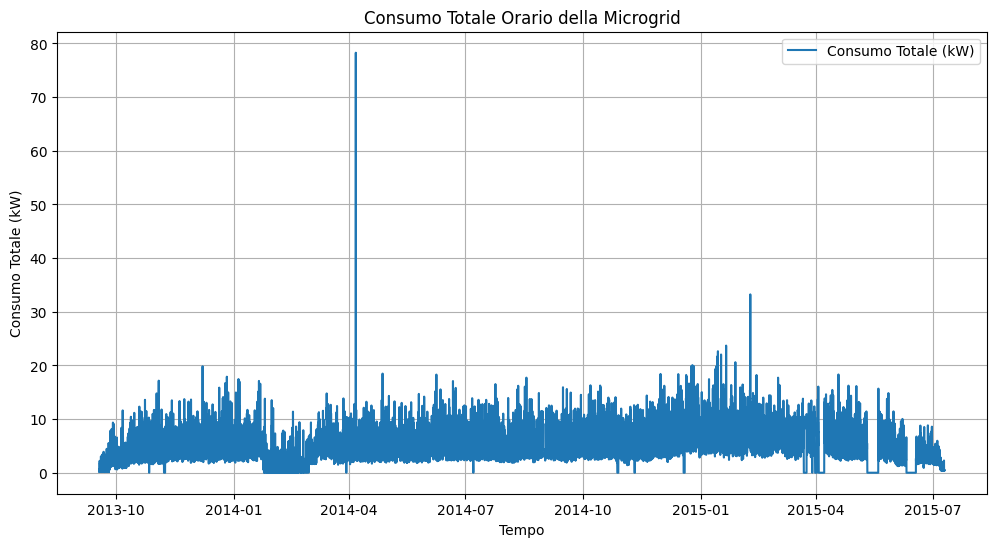

In [5]:
#Calcolo la somma del consumo totale orario della microgrid nella colonna Total_Load
Tabella_Load_temp["Total_Load"] = Tabella_Load_temp.sum(axis=1)


# Grafico per visualizzare il consumo totale orario
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(Tabella_Load_temp.index, Tabella_Load_temp["Total_Load"], label="Consumo Totale (kW)")
plt.xlabel("Tempo")
plt.ylabel("Consumo Totale (kW)")
plt.title("Consumo Totale Orario della Microgrid")
plt.legend()
plt.grid()
plt.show()


In [6]:
#Controlliamo quanti valori nella colonna Time sono duplicati
print(Tabella_Load_temp.index.duplicated().sum())

#Controlliamo se ci sono valori mancanti tra il minimo e il massimo della colonna Time, ora per ora
print(Tabella_Load_temp.index.isnull().sum())
print(Tabella_Load_temp.index.min())
print(Tabella_Load_temp.index.max())

#Controlliamo quanti valori NaN ci sono nelle colonne House1, House2, House3, House4, House5, House11 e Total_Load
print(Tabella_Load_temp.isna().sum())

0
0
2013-09-17 22:00:00
2015-07-10 11:00:00
House1        2334
House2        4500
House3        2722
House4        2270
House5        1319
House11       7437
Total_Load       0
dtype: int64


In [7]:
cols = ["House1", "House2", "House3", "House4", "House5", "House11"]

# 1) togli outlier assurdi
Tabella_Load_temp[cols] = Tabella_Load_temp[cols].mask(Tabella_Load_temp[cols] > 20)

# 2) interpolazione per gap brevi
Tabella_Load_temp[cols] = Tabella_Load_temp[cols].interpolate(method="time", limit=3)

# 3) fill limitato avanti/indietro
Tabella_Load_temp[cols] = Tabella_Load_temp[cols].ffill(limit=6).bfill(limit=6)

# 4) per i NaN rimasti, usa il profilo medio per ora del giorno
hourly_profile = Tabella_Load_temp[cols].groupby(Tabella_Load_temp.index.hour).transform("mean")
Tabella_Load_temp[cols] = Tabella_Load_temp[cols].fillna(hourly_profile)

# 5) ricrea il total load in modo corretto
Tabella_Load_temp["Total_Load"] = Tabella_Load_temp[cols].sum(axis=1, min_count=len(cols))

print(Tabella_Load_temp.isna().sum())

House1        0
House2        0
House3        0
House4        0
House5        0
House11       0
Total_Load    0
dtype: int64


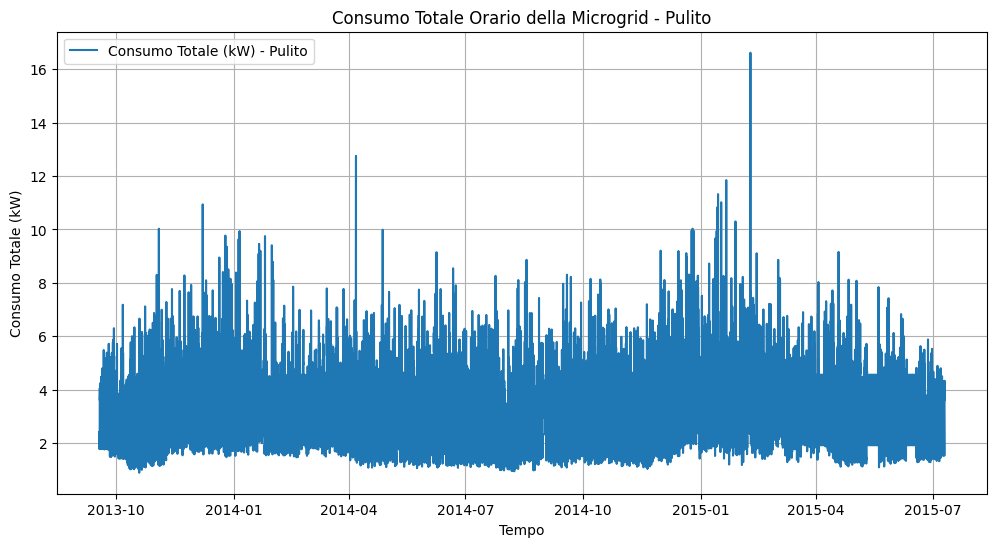

In [8]:
#Grafico per visualizzare il consumo totale orario dopo la pulizia dei dati
plt.figure(figsize=(12, 6))
plt.plot(Tabella_Load_temp.index, Tabella_Load_temp["Total_Load"], label="Consumo Totale (kW) - Pulito")
plt.xlabel("Tempo")
plt.ylabel("Consumo Totale (kW)")
plt.title("Consumo Totale Orario della Microgrid - Pulito")
plt.legend()
plt.grid()
plt.show()


In [9]:
#Tolgo il primo e l'ultimo giorno che non hanno le misurazioni complete
Tabella_Load_temp = Tabella_Load_temp[
    (Tabella_Load_temp.index >= "2013-09-18 00:00:00") &
    (Tabella_Load_temp.index <= "2015-07-09 23:00:0")
]
print(Tabella_Load_temp.index)

DatetimeIndex(['2013-09-18 00:00:00', '2013-09-18 01:00:00',
               '2013-09-18 02:00:00', '2013-09-18 03:00:00',
               '2013-09-18 04:00:00', '2013-09-18 05:00:00',
               '2013-09-18 06:00:00', '2013-09-18 07:00:00',
               '2013-09-18 08:00:00', '2013-09-18 09:00:00',
               ...
               '2015-07-09 14:00:00', '2015-07-09 15:00:00',
               '2015-07-09 16:00:00', '2015-07-09 17:00:00',
               '2015-07-09 18:00:00', '2015-07-09 19:00:00',
               '2015-07-09 20:00:00', '2015-07-09 21:00:00',
               '2015-07-09 22:00:00', '2015-07-09 23:00:00'],
              dtype='datetime64[us]', name='Time', length=15840, freq='h')


Time
2013-09-18    73.664966
2013-09-19    73.117217
2013-09-20    74.749862
2013-09-21    72.473804
2013-09-22    73.241473
                ...    
2015-07-05    71.830485
2015-07-06    68.328203
2015-07-07    72.959583
2015-07-08    74.045674
2015-07-09    71.437732
Freq: D, Name: Total_Load, Length: 660, dtype: float64


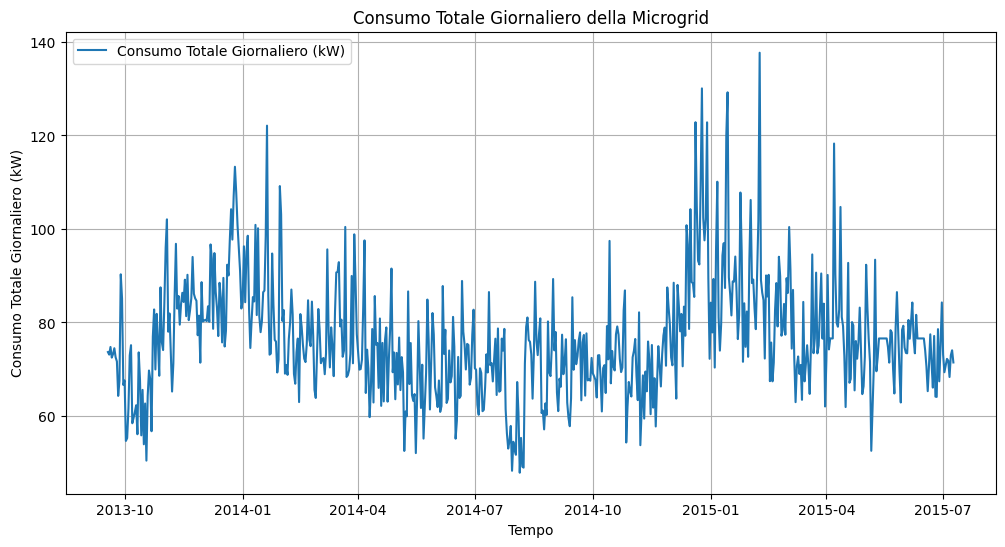

In [10]:
#Calcolo il consumo totale giornaliero della microgrid, raggruppando i valori della colonna Total_Load per giorno e sommando i valori di ogni giorno
Tabella_Load_daily = Tabella_Load_temp["Total_Load"].resample("D").sum()
print(Tabella_Load_daily)

#Grafico per visualizzare il consumo totale giornaliero della microgrid
plt.figure(figsize=(12, 6))
plt.plot(Tabella_Load_daily.index, Tabella_Load_daily.values, label="Consumo Totale Giornaliero (kW)")
plt.xlabel("Tempo")
plt.ylabel("Consumo Totale Giornaliero (kW)")
plt.title("Consumo Totale Giornaliero della Microgrid")
plt.legend()
plt.grid()
plt.show()


In [11]:
#Consumo totale di energia elettrica nel 2014 del Regno Unito
total_consum_RE2014 = 303.4 #TWh
#Consumo totale di energia elettrica nel 2024 del Regno Unito
total_consum_RE2024 = 272.4 #TWh
print(f"Il consumo totale di energia elettrica nel 2014 del Regno Unito è: {total_consum_RE2014} TWh")
print(f"Il consumo totale di energia elettrica nel 2024 del Regno Unito è: {total_consum_RE2024} TWh")

#Rapporto tra il consumo totale di energia elettrica nel 2014 e nel 2024 del Regno Unito
rapporto_consum_RE = total_consum_RE2024 / total_consum_RE2014
print(f"Il rapporto tra il consumo totale di energia elettrica nel 2014 e nel 2024 del Regno Unito è: {rapporto_consum_RE:.2f}")

#Calcolo il consumo totale in tutto il 2014, considerando che Time ha questo formato: 2013-09-18 
consumo_totale_2014 = Tabella_Load_daily.loc['2014'].sum()
print(f"Il consumo totale in tutto il 2014 delle 6 case è: {consumo_totale_2014} kWh")

#Moltiplico tutte le colonne House1, House2, House3, House4, House5 e House11 per il rapporto tra il consumo totale di energia elettrica nel 2014 e nel 2024 del Regno Unito, in modo da scalare i consumi delle case al consumo totale del Regno Unito nel 2024
Tabella_Load_temp[cols] = Tabella_Load_temp[cols] * rapporto_consum_RE
print(Tabella_Load_temp)


Il consumo totale di energia elettrica nel 2014 del Regno Unito è: 303.4 TWh
Il consumo totale di energia elettrica nel 2024 del Regno Unito è: 272.4 TWh
Il rapporto tra il consumo totale di energia elettrica nel 2014 e nel 2024 del Regno Unito è: 0.90
Il consumo totale in tutto il 2014 delle 6 case è: 27121.293469419626 kWh
                       House1    House2    House3    House4    House5  \
Time                                                                    
2013-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
2013-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2013-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
2013-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
2013-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   
...                       ...       ...       ...       ...       ...   
2015-07-09 19:00:00  0.177212  0.595558  0.763069  0.428158  0.980657   
2015-07-09 20:00

Time
2013-09-18    73.664966
2013-09-19    73.117217
2013-09-20    74.749862
2013-09-21    72.473804
2013-09-22    73.241473
                ...    
2015-07-05    71.830485
2015-07-06    68.328203
2015-07-07    72.959583
2015-07-08    74.045674
2015-07-09    71.437732
Freq: D, Name: Total_Load, Length: 660, dtype: float64


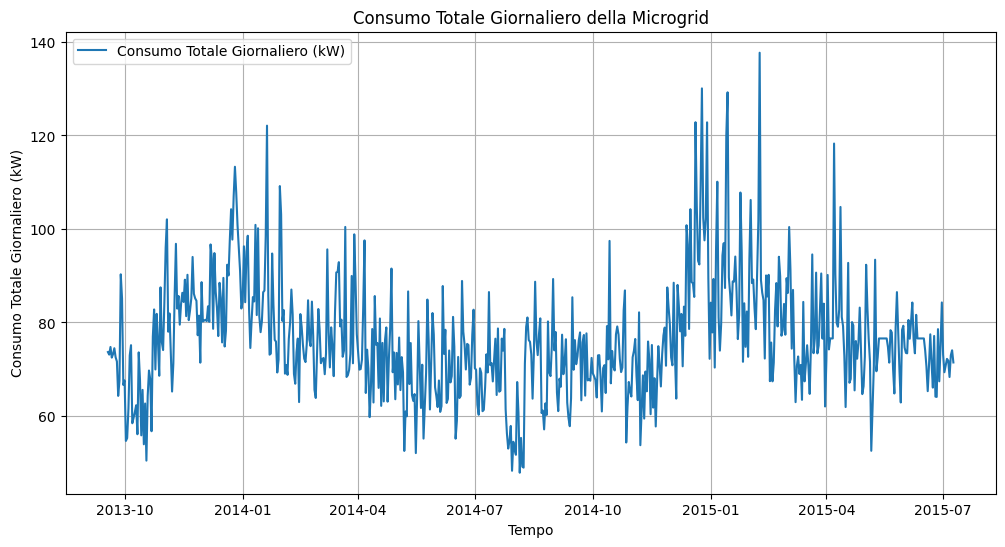

In [12]:
#Calcolo il consumo totale giornaliero della microgrid, raggruppando i valori della colonna Total_Load per giorno e sommando i valori di ogni giorno
Tabella_Load_daily = Tabella_Load_temp["Total_Load"].resample("D").sum()
print(Tabella_Load_daily)

#Grafico per visualizzare il consumo totale giornaliero della microgrid
plt.figure(figsize=(12, 6))
plt.plot(Tabella_Load_daily.index, Tabella_Load_daily.values, label="Consumo Totale Giornaliero (kW)")
plt.xlabel("Tempo")
plt.ylabel("Consumo Totale Giornaliero (kW)")
plt.title("Consumo Totale Giornaliero della Microgrid")
plt.legend()
plt.grid()
plt.show()

In [13]:
#Aumento di 10 anni la colonna Time
Tabella_Load_temp.index = pd.to_datetime(Tabella_Load_temp.index) + pd.DateOffset(years=10)

#L'indice Time diventa la colonna DateTime
Tabella_Load = Tabella_Load_temp.reset_index()
Tabella_Load = Tabella_Load.rename(columns={"index": "DateTime"})
print(Tabella_Load)

# Salvo Tabella_Load in un file csv con il nome "Tabella_Load.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Load.to_csv(r"C:\Users\vinsc\Documents\Progetti\Tabella_Load.csv", index=True)
    

                     Time    House1    House2    House3    House4    House5  \
0     2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1     2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2     2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3     2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4     2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   
...                   ...       ...       ...       ...       ...       ...   
15835 2025-07-09 19:00:00  0.177212  0.595558  0.763069  0.428158  0.980657   
15836 2025-07-09 20:00:00  0.193448  0.576140  0.677864  0.381736  0.858430   
15837 2025-07-09 21:00:00  0.327061  0.452952  0.600769  0.367718  0.590036   
15838 2025-07-09 22:00:00  0.387223  0.339174  0.475246  0.323019  0.408734   
15839 2025-07-09 23:00:00  1.021766  0.267694  0.331203  0.290083  0.362284   

        House11  Total_Load  
0      0.209238    1.